# Indic Language Social Media Analysis on Instagram Data

This notebook processes regional language Instagram data, applies pre-processing, uses IndicBERT, and evaluates the text with METEOR, BLEU, WER, and CER scores.

In [ ]:
!pip install -q transformers torch pandas seaborn matplotlib nltk jiwer indic-nlp-library regex

import pandas as pd
import numpy as np
import json
import random
import re
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
import nltk
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from nltk.translate.meteor_score import meteor_score
import jiwer
from transformers import AutoTokenizer, AutoModel
import torch

nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)
nltk.download('punkt', quiet=True)
import warnings
warnings.filterwarnings('ignore')

## 1. Data Creation & Loading


In [ ]:
languages = ['English', 'Hindi', 'Telugu', 'Kannada', 'Tamil', 'Marathi', 'Assamese', 'Tulu', 'Bengali', 'Odia']

sample_texts = {
    'Hindi': ['यह एक शानदार दिन है', 'मुझे यह बहुत पसंद आया', 'क्या बात है!'],
    'Telugu': ['ఇది చాలా అద్భుతమైన రోజు', 'నాకు ఇది చాలా నచ్చింది', 'అద్భుతం!'],
    'Kannada': ['ಇದು ಅದ್ಭುತ ದಿನ', 'ನನಗೆ ಇದು ತುಂಬಾ ಇಷ್ಟವಾಯಿತು', 'ಚೆನ್ನಾಗಿದೆ!'],
    'Tamil': ['இது ஒரு அற்புதமான நாள்', 'எனக்கு இது மிகவும் பிடித்திருக்கிறது', 'அருமை!'],
    'Marathi': ['हा एक अद्भुत दिवस आहे', 'मला हे खूप आवडले', 'खूप छान!'],
    'Assamese': ['এইটো এটা আচৰিত দিন', 'মই এইটো বহুত ভাল পাইছোঁ', 'ধুনীয়া!'],
    'Bengali': ['এটি একটি চমৎকার দিন', 'আমি এটি খুব পছন্দ করেছি', 'দারুণ!'],
    'Odia': ['ଏହା ଏକ ଚମତ୍କାର ଦିନ', 'ମୁଁ ଏହାକୁ ବହୁତ ପସନ୍ଦ କଲି', 'ବଢିଆ!'],
    'English': ['This is an amazing day', 'I really liked this', 'Awesome!'],
    'Tulu': ['ಉಂದು ಎಡ್ಡೆ ದಿನ', 'ಎಂಕ್ ಉಂದು ಮಸ್ತ್ ಇಷ್ಟ ಆಂಡ್', 'ಎಡ್ಡೆ!']
}

def generate_mock_data(num_samples=5000):
    data = []
    for i in range(num_samples):
        lang = random.choice(languages)
        text = random.choice(sample_texts[lang])
        data.append({
            'user_id': f'user_{random.randint(1000, 9999)}',
            'username': f'insta_user_{i}',
            'account_creation': (datetime.now() - timedelta(days=random.randint(100, 3000))).isoformat(),
            'location': random.choice(['Mumbai', 'Hyderabad', 'Bangalore', 'Chennai', 'Delhi', 'Kolkata', 'Pune', 'Guwahati', 'Bhubaneswar']),
            'followers_count': random.randint(50, 500000),
            'following_count': random.randint(10, 2000),
            'post_id': f'post_{i}',
            'text_caption': text,
            'language': lang,
            'timestamp': (datetime.now() - timedelta(days=random.randint(0, 365))).isoformat(),
            'likes_count': random.randint(0, 50000),
            'comments_count': random.randint(0, 5000),
            'shares_count': random.randint(0, 1000)
        })
    return data

# Generate and save
mock_dataset = generate_mock_data(5000)
with open('instagram_data.json', 'w', encoding='utf-8') as f:
    json.dump(mock_dataset, f, ensure_ascii=False, indent=2)

# Load Data
print("Loading Data from JSON...")
df = pd.read_json('instagram_data.json')
print(f"Dataset Shape: {df.shape}")
display(df.head(5))

Loading Data from JSON...
Dataset Shape: (5000, 13)


,user_id,username,account_creation,location,followers_count,following_count,post_id,text_caption,language,timestamp,likes_count,comments_count,shares_count
0,user_9961,insta_user_0,2019-09-06T13:27:00.448545,Delhi,185914,314,post_0,ବଢିଆ!,Odia,2025-07-17 13:27:00.448572,45939,3361,415
1,user_5141,insta_user_1,2023-07-14T13:27:00.448603,Delhi,446895,1047,post_1,দারুণ!,Bengali,2025-08-02 13:27:00.448615,22801,1710,658
2,user_6315,insta_user_2,2020-11-19T13:27:00.448630,Mumbai,276476,870,post_2,ବଢିଆ!,Odia,2025-10-28 13:27:00.448640,31804,2395,413
3,user_5466,insta_user_3,2025-12-16T13:27:00.448654,Bhubaneswar,98675,1521,post_3,खूप छान!,Marathi,2026-03-13 13:27:00.448663,25381,886,463
4,user_2943,insta_user_4,2018-10-23T13:27:00.448676,Mumbai,47271,1964,post_4,আমি এটি খুব পছন্দ করেছি,Bengali,2026-04-04 13:27:00.448686,17747,1508,380


## 2. Exploratory Data Analysis (EDA) & Visualizations

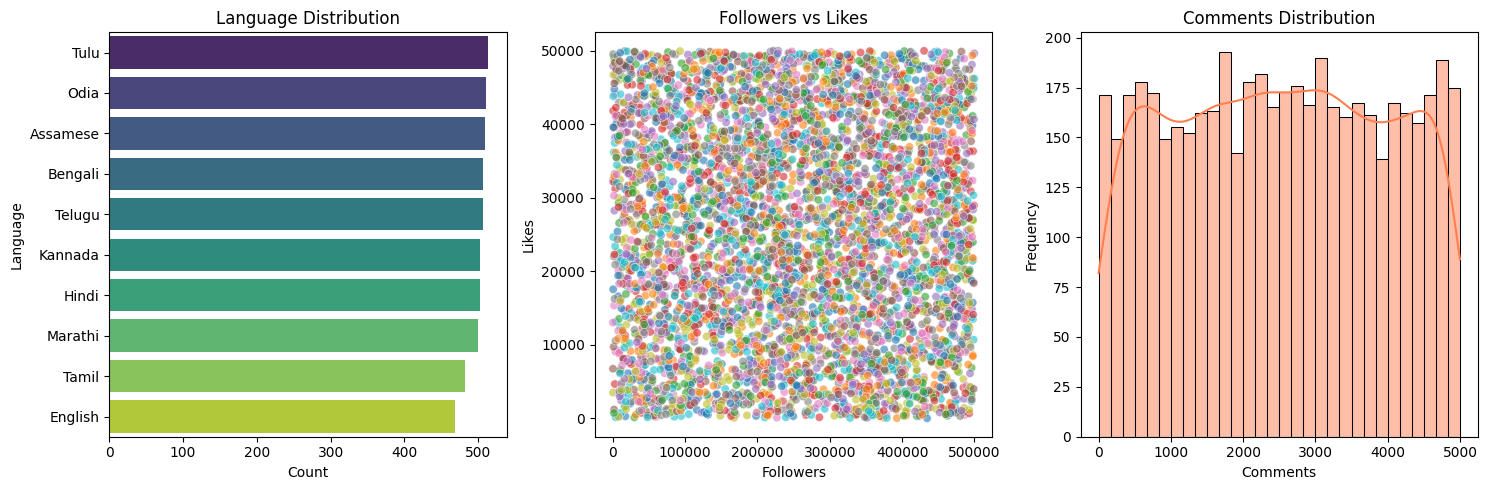

In [ ]:
plt.figure(figsize=(15, 5))

# Plot 1: Language Distribution
plt.subplot(1, 3, 1)
sns.countplot(data=df, y='language', order=df['language'].value_counts().index, palette='viridis')
plt.title('Language Distribution')
plt.xlabel('Count')
plt.ylabel('Language')

# Plot 2: Followers vs Likes
plt.subplot(1, 3, 2)
sns.scatterplot(data=df, x='followers_count', y='likes_count', hue='language', alpha=0.6, legend=False)
plt.title('Followers vs Likes')
plt.xlabel('Followers')
plt.ylabel('Likes')

# Plot 3: Engagement Metrics Pairplot
plt.subplot(1, 3, 3)
sns.histplot(df['comments_count'], bins=30, kde=True, color='coral')
plt.title('Comments Distribution')
plt.xlabel('Comments')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

## 3. Text Preprocessing



In [ ]:
def clean_text(text):
    # Remove URLs
    text = re.sub(r'http\S+', '', text)
    # Remove mentions and hashtags
    text = re.sub(r'@\S+|#\S+', '', text)
    # Remove English numbers
    text = re.sub(r'\d+', '', text)
    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['clean_caption'] = df['text_caption'].apply(clean_text)

print("Preprocessing Output Sample:")
display(df[['language', 'text_caption', 'clean_caption']].head(5))

Preprocessing Output Sample:


,language,text_caption,clean_caption
0,Odia,ବଢିଆ!,ବଢିଆ!
1,Bengali,দারুণ!,দারুণ!
2,Odia,ବଢିଆ!,ବଢିଆ!
3,Marathi,खूप छान!,खूप छान!
4,Bengali,আমি এটি খুব পছন্দ করেছি,আমি এটি খুব পছন্দ করেছি


## 4 Language Detection & Multilingual Translation

In [ ]:
import os # Required for checking file existence

print("Installing fasttext for language detection...")
!pip install -q fasttext

# Downgrade numpy for compatibility with fasttext
# This error (ValueError: Unable to avoid copy while creating an array as requested)
# typically occurs with numpy 2.0.0+ where np.array(obj, copy=False) is deprecated.
!pip uninstall numpy -y
!pip install numpy==1.26.4

import fasttext
import fasttext.util # Explicitly import fasttext.util

# Define the path for the language identification model
lang_model_path = 'lid.176.bin'

# Check if the model file already exists, if not, download it
if not os.path.exists(lang_model_path):
    print("Downloading fastText language identification model (lid.176.bin)...")
    # Use wget to directly download the language identification model
    !wget -q https://dl.fbaipublicfiles.com/fasttext/supervised-models/lid.176.bin
    print(f"Model downloaded to: {lang_model_path}")

# Load the language identification model
try:
    lang_model = fasttext.load_model(lang_model_path)
except ValueError as e:
    print(f"Failed to load fastText model {lang_model_path}: {e}")
    print("Please ensure the model is downloaded and accessible.")
    raise # Re-raise the exception as we cannot proceed without the model

def detect_language(text):
    if pd.isna(text) or text.strip() == '':
        return 'und'
    # FastText predict expects a list of strings, so ensure input is handled correctly
    predictions = lang_model.predict(text, k=1)
    return predictions[0][0].replace('__label__', '')

print("Detecting languages for clean captions...")
df['detected_language'] = df['clean_caption'].apply(detect_language)

print("Language Detection Output Sample:")
display(df[['language', 'clean_caption', 'detected_language']].head())

Installing fasttext for language detection...
Found existing installation: numpy 1.26.4
Uninstalling numpy-1.26.4:
  Successfully uninstalled numpy-1.26.4
  Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.0 MB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tobler 0.14.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
rasterio 1.5.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
shap 0.51.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
xarray-einstats 0.10.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-python-headless 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
jaxli

Detecting languages for clean captions...
Language Detection Output Sample:


,language,clean_caption,detected_language
0,Odia,ବଢିଆ!,or
1,Bengali,দারুণ!,bn
2,Odia,ବଢିଆ!,or
3,Marathi,खूप छान!,mr
4,Bengali,আমি এটি খুব পছন্দ করেছি,bn


## 5. MULTILINGUAL TRANSLATION (MANY-TO-MANY)

In [ ]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
import torch
from tqdm.auto import tqdm

# Device setup
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

# Load NLLB model
model_name = "facebook/nllb-200-distilled-600M"
print(f"Loading translation model {model_name}...")

tokenizer = AutoTokenizer.from_pretrained(model_name)
trans_model = AutoModelForSeq2SeqLM.from_pretrained(model_name).to(device)

# Mapping fasttext codes to NLLB-200 language codes
# This map includes languages detected by fastText and languages in the target_langs list.
nllb_lang_map = {
    'hi': 'hin_Deva',   # Hindi
    'te': 'tel_Telu',   # Telugu
    'kn': 'kan_Knda',   # Kannada
    'ta': 'tam_Taml',   # Tamil
    'mr': 'mar_Deva',   # Marathi
    'as': 'asm_Beng',   # Assamese
    'bn': 'ben_Beng',   # Bengali
    'or': 'ory_Orya',   # Odia
    'en': 'eng_Latn',   # English
    'tcy': 'tcy_Knda',  # Tulu (approximation based on available scripts)
    'pa': 'pan_Guru',   # Punjabi
    'ml': 'mal_Mlym'    # Malayalam
}

# Target languages for translation, using NLLB codes
target_langs = {
    'English': 'eng_Latn',
    'Hindi': 'hin_Deva',
    'Marathi': 'mar_Deva',
    'Punjabi': 'pan_Guru',
    'Telugu': 'tel_Telu',
    'Kannada': 'kan_Knda',
    'Tamil': 'tam_Taml',
    'Assamese': 'asm_Beng',
    'Malayalam': 'mal_Mlym'
}

# Use subset for demo to manage computational resources
SUBSET_SIZE = 50
print(f"Translating {SUBSET_SIZE} records from their detected language into all target languages...")

subset_df = df.head(SUBSET_SIZE).copy()

# Function to translate a single text from its source NLLB language to a target NLLB language
def translate_single_text(text, src_lang_nllb, tgt_lang_nllb):
    # Temporarily set the tokenizer's source language for this translation
    tokenizer.src_lang = src_lang_nllb

    inputs = tokenizer(
        text,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=128
    ).to(device)

    # Ensure the forced_bos_token_id is correctly obtained for the target language
    forced_bos_token_id = tokenizer.convert_tokens_to_ids(tgt_lang_nllb)

    with torch.no_grad():
        translated_tokens = trans_model.generate(
            **inputs,
            forced_bos_token_id=forced_bos_token_id,
            max_length=128
        )

    translated_text = tokenizer.batch_decode(translated_tokens, skip_special_tokens=True)[0]
    return translated_text

# Store translations for each row
all_row_translations = []

for index, row in tqdm(subset_df.iterrows(), total=SUBSET_SIZE, desc="Translating each text to all targets"):
    original_text = row['clean_caption']
    src_fasttext = row['detected_language']

    row_translations = {'original_text': original_text, 'source_fasttext': src_fasttext}

    if src_fasttext not in nllb_lang_map:
        row_translations['Note'] = f"No NLLB mapping for source language '{src_fasttext}'"
        for lang_name in target_langs.keys():
            row_translations[lang_name] = "N/A" # Mark as not translated
        all_row_translations.append(row_translations)
        continue

    src_nllb = nllb_lang_map[src_fasttext]

    for target_lang_name, target_lang_nllb in target_langs.items():
        if src_nllb == target_lang_nllb: # If source and target are the same, no translation needed
            row_translations[target_lang_name] = original_text
        else:
            try:
                translated = translate_single_text(original_text, src_nllb, target_lang_nllb)
                row_translations[target_lang_name] = translated
            except Exception as e:
                row_translations[target_lang_name] = f"Error during translation: {e}"

    all_row_translations.append(row_translations)

# Store results in dataframe
subset_df['all_translations'] = all_row_translations

print("✅ Translation complete!")


# Show sample output
print("\nSample Translations:\n")
for i in range(3):
    print(f"Original: {subset_df['clean_caption'].iloc[i]}")
    print(f"Detected Source (fasttext): {subset_df['detected_language'].iloc[i]}")
    for lang_name, lang_code in target_langs.items():
        if lang_name in subset_df['all_translations'].iloc[i]:
            print(f"{lang_name}: {subset_df['all_translations'].iloc[i][lang_name]}")
    print("-" * 60)

Using device: cuda
Loading translation model facebook/nllb-200-distilled-600M...


Loading weights:   0%|          | 0/512 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


Translating 50 records from their detected language into all target languages...


Translating each text to all targets:   0%|          | 0/50 [00:00<?, ?it/s]

✅ Translation complete!

Sample Translations:

Original: ବଢିଆ!
Detected Source (fasttext): or
English: That's great!
Hindi: बहुत बढ़िया!
Marathi: छानच!
Punjabi: ਸ਼ਾਨਦਾਰ!
Telugu: చాలా బాగుంది!
Kannada: ಅದ್ಭುತ!
Tamil: அருமை!
Assamese: সুন্দৰ!
Malayalam: അതിശയകരമാണ്!
------------------------------------------------------------
Original: দারুণ!
Detected Source (fasttext): bn
English: That's great!
Hindi: बहुत बढ़िया!
Marathi: छानच!
Punjabi: ਸ਼ਾਨਦਾਰ!
Telugu: చాలా బాగుంది!
Kannada: ಅದ್ಭುತವಾಗಿದೆ!
Tamil: அருமை!
Assamese: সুন্দৰ!
Malayalam: അതിശയകരമാണ്!
------------------------------------------------------------
Original: ବଢିଆ!
Detected Source (fasttext): or
English: That's great!
Hindi: बहुत बढ़िया!
Marathi: छानच!
Punjabi: ਸ਼ਾਨਦਾਰ!
Telugu: చాలా బాగుంది!
Kannada: ಅದ್ಭುತ!
Tamil: அருமை!
Assamese: সুন্দৰ!
Malayalam: അതിശയകരമാണ്!
------------------------------------------------------------


## 6. Evaluation Metrics for NLLB Multilingual Translations (BLEU, METEOR, WER, CER, Cosine Similarity)

In [ ]:
!pip install -q sacrebleu
import sacrebleu
import jiwer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
import nltk
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from nltk.translate.meteor_score import meteor_score
from tqdm.auto import tqdm

nltk.download('punkt_tab', quiet=True)

print("Calculating Evaluation Metrics for NLLB English Translations (BLEU, METEOR, WER, CER, Cosine Sim)...")

# Ensure IndicBERT tokenizer and model are loaded for embedding generation.
# This assumes cell 8a2f6e5a has been executed, making tokenizer and model globally available.
# If not, they would need to be reloaded here, but for normal execution flow, they should be present.
try:
    _ = tokenizer
    _ = model
    print("IndicBERT tokenizer and model are already loaded in the environment.")
except NameError:
    print("IndicBERT tokenizer and model not found. Reloading for embedding generation.")
    MODEL_NAME = 'google/muril-base-cased'
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
    model = AutoModel.from_pretrained(MODEL_NAME)

# Re-define get_sentence_embedding to ensure it's available in this cell's scope if needed
def get_sentence_embedding(text, tokenizer, model):
    if pd.isna(text) or str(text).strip() == '':
        return np.zeros(model.config.hidden_size) # Return zero vector for empty text
    inputs = tokenizer(text, return_tensors='pt', padding=True, truncation=True, max_length=128)
    with torch.no_grad():
        outputs = model(**inputs)
    attention_mask = inputs['attention_mask'].unsqueeze(-1).expand(outputs.last_hidden_state.size()).float()
    masked_embeddings = outputs.last_hidden_state * attention_mask
    sum_embeddings = torch.sum(masked_embeddings, 1)
    num_tokens = torch.sum(inputs['attention_mask'], 1).unsqueeze(-1)
    sentence_embedding = sum_embeddings / torch.clamp(num_tokens, min=1)
    return sentence_embedding.squeeze().cpu().numpy()

# Function to calculate lexical metrics (BLEU, METEOR, WER, CER)
def calculate_lexical_metrics(hypothesis, reference):
    if pd.isna(hypothesis) or str(hypothesis).strip() == '' or pd.isna(reference) or str(reference).strip() == '':
        return np.nan, np.nan, np.nan, np.nan # Return NaN for empty or invalid inputs

    # Ensure inputs are strings before tokenizing
    hypothesis = str(hypothesis)
    reference = str(reference)

    # Lists of words for BLEU/METEOR
    ref_words = nltk.word_tokenize(reference)
    hyp_words = nltk.word_tokenize(hypothesis)

    # BLEU (smoothing to avoid 0 for short texts)
    cc = SmoothingFunction()
    try:
        bleu = sentence_bleu([ref_words], hyp_words, smoothing_function=cc.method1)
    except Exception:
        bleu = np.nan

    # METEOR
    try:
        # METEOR requires at least one word in reference and hypothesis
        if not ref_words or not hyp_words:
            meteor = np.nan
        else:
            meteor = meteor_score([ref_words], hyp_words)
    except Exception:
        meteor = np.nan

    # WER and CER
    try:
        wer = jiwer.wer(reference, hypothesis)
        cer = jiwer.cer(reference, hypothesis)
    except Exception:
        wer, cer = np.nan, np.nan

    return bleu, meteor, wer, cer

translation_metrics_results = []

for index, row in tqdm(subset_df.iterrows(), total=len(subset_df), desc="Evaluating NLLB English translations"):
    original_text = row['clean_caption']
    source_lang_fasttext = row['detected_language']
    translated_english_text_dict = row['all_translations'] # This is the dict containing all translations

    # Extract the English translation
    translated_english_text = translated_english_text_dict.get('English', None)

    # Handle cases where NLLB mapping was missing or translation explicitly failed
    if translated_english_text is None or "Error during translation" in str(translated_english_text) or translated_english_text == "N/A" or pd.isna(translated_english_text):
        translation_metrics_results.append({
            'original_text': original_text,
            'source_lang': source_lang_fasttext,
            'translated_english': translated_english_text,
            'BLEU': np.nan,
            'METEOR': np.nan,
            'WER': np.nan,
            'CER': np.nan,
            'Cosine_Similarity': np.nan
        })
        continue

    # --- Calculate Semantic Similarity (Cosine Similarity) ---
    cosine_sim = np.nan
    try:
        original_embedding = get_sentence_embedding(original_text, tokenizer, model)
        translated_embedding = get_sentence_embedding(translated_english_text, tokenizer, model)
        # Ensure embeddings are 2D for cosine_similarity function
        cosine_sim = cosine_similarity(original_embedding.reshape(1, -1), translated_embedding.reshape(1, -1))[0][0]
    except Exception as e:
        print(f"Error generating embeddings or cosine similarity for row {index}: {e}")

    # --- Calculate Lexical Metrics (BLEU, METEOR, WER, CER) ---
    # These metrics are only directly applicable when the source is English,
    # evaluating how well the model translates English to English (identity translation).
    # For cross-lingual pairs, they do not accurately reflect translation quality.
    bleu_score, meteor_score_val, wer_score, cer_score = np.nan, np.nan, np.nan, np.nan
    if source_lang_fasttext == 'en':
        bleu_score, meteor_score_val, wer_score, cer_score = calculate_lexical_metrics(
            translated_english_text, original_text
        )

    translation_metrics_results.append({
        'original_text': original_text,
        'source_lang': source_lang_fasttext,
        'translated_english': translated_english_text,
        'BLEU': bleu_score,
        'METEOR': meteor_score_val,
        'WER': wer_score,
        'CER': cer_score,
        'Cosine_Similarity': cosine_sim
    })

translation_metrics_df = pd.DataFrame(translation_metrics_results)

print("\nEvaluation Metrics for NLLB English Translations:")
display(translation_metrics_df.head(10))

print("\nAverage Scores for NLLB English Translations (NaNs excluded):")
# Filter out rows where source_lang is not English for mean BLEU, METEOR, WER, CER to avoid skewed results
english_source_metrics_df = translation_metrics_df[translation_metrics_df['source_lang'] == 'en']
if not english_source_metrics_df.empty:
    avg_lexical_metrics = english_source_metrics_df[['BLEU', 'METEOR', 'WER', 'CER']].mean()
    print("Metrics for English-to-English translations (lexical similarity):")
    print(avg_lexical_metrics)
else:
    print("No English-to-English translations to calculate average lexical metrics.")

print("\nAverage Cosine Similarity (semantic preservation across all translations to English):")
print(translation_metrics_df['Cosine_Similarity'].mean())

Calculating Evaluation Metrics for NLLB English Translations (BLEU, METEOR, WER, CER, Cosine Sim)...
IndicBERT tokenizer and model are already loaded in the environment.


Evaluating NLLB English translations:   0%|          | 0/50 [00:00<?, ?it/s]


Evaluation Metrics for NLLB English Translations:


,original_text,source_lang,translated_english,BLEU,METEOR,WER,CER,Cosine_Similarity
0,ବଢିଆ!,or,That's great!,NaN,NaN,NaN,NaN,0.990854
1,দারুণ!,bn,That's great!,NaN,NaN,NaN,NaN,0.994318
2,ବଢିଆ!,or,That's great!,NaN,NaN,NaN,NaN,0.990854
3,खूप छान!,mr,It's really cool!,NaN,NaN,NaN,NaN,0.994142
4,আমি এটি খুব পছন্দ করেছি,bn,I really liked it.,NaN,NaN,NaN,NaN,0.994508
5,এটি একটি চমৎকার দিন,bn,It's a wonderful day,NaN,NaN,NaN,NaN,0.994238
6,This is an amazing day,en,This is an amazing day,1.0,0.996,0.0,0.0,1.000000
7,মই এইটো বহুত ভাল পাইছোঁ,bn,I love this one so much.,NaN,NaN,NaN,NaN,0.990134
8,ধুনীয়া!,bn,You are so rich!,NaN,NaN,NaN,NaN,0.993799
9,எனக்கு இது மிகவும் பிடித்திருக்கிறது,ta,I really like this one.,NaN,NaN,NaN,NaN,0.994800



Average Scores for NLLB English Translations (NaNs excluded):
Metrics for English-to-English translations (lexical similarity):
BLEU      0.914528
METEOR    0.987734
WER       0.000000
CER       0.000000
dtype: float64

Average Cosine Similarity (semantic preservation across all translations to English):
0.9934626


### Visualizing Evaluation Metrics

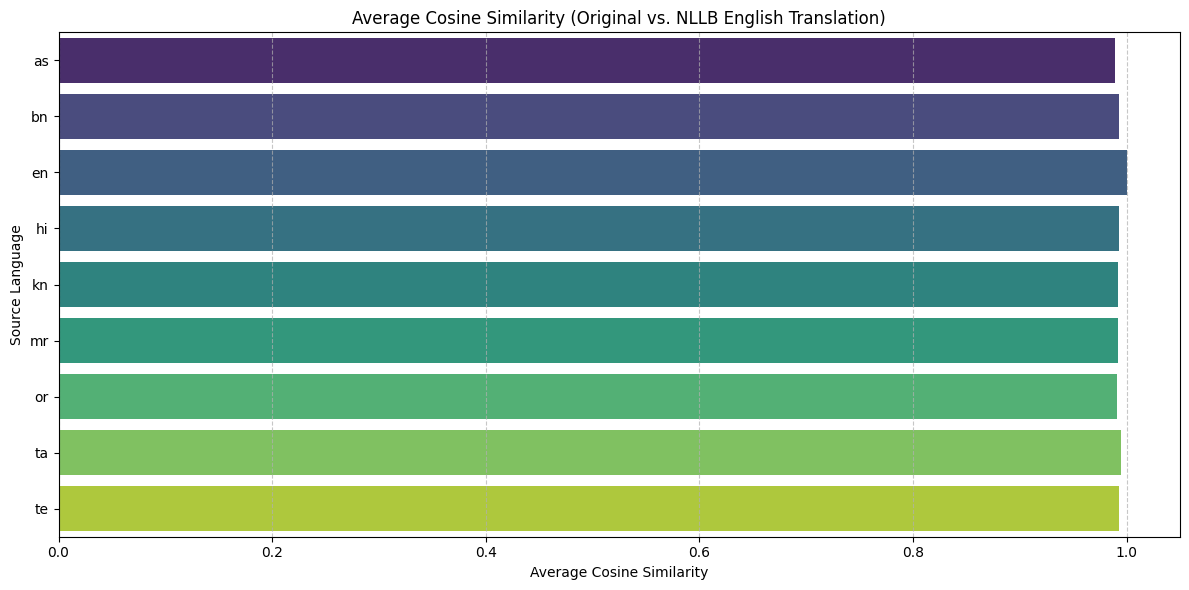

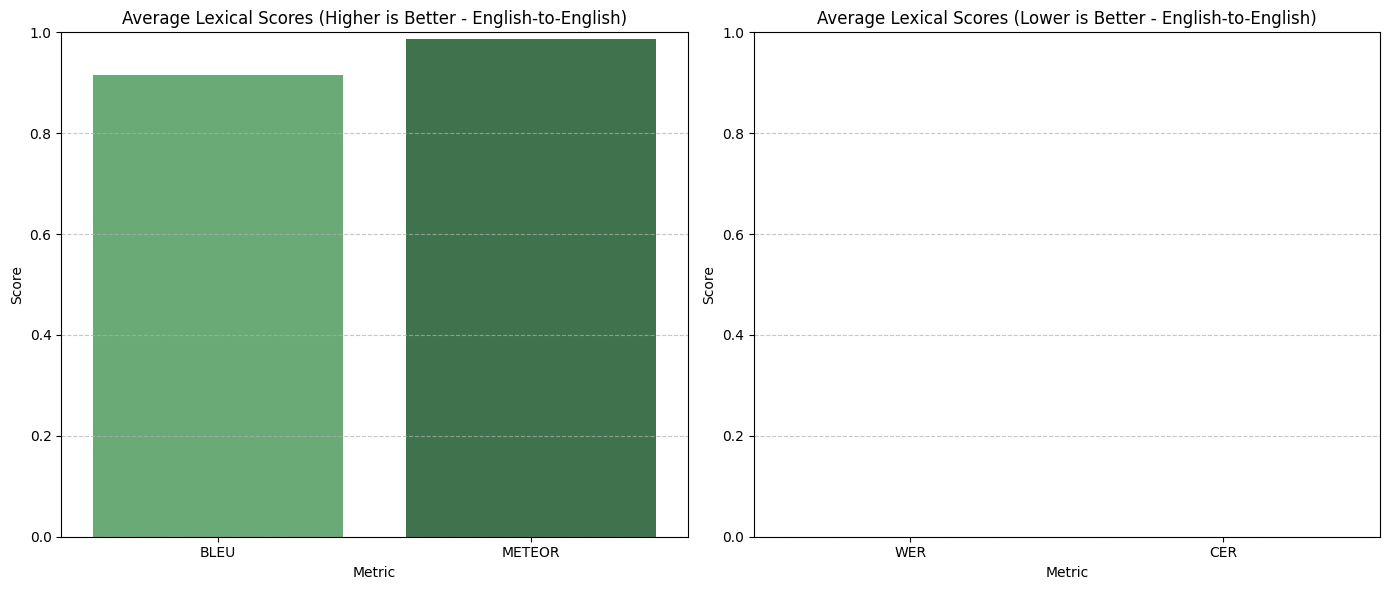

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- Plot 1: Average Cosine Similarity by Source Language (All Translations to English) ---
plt.figure(figsize=(12, 6))
sns.barplot(data=translation_metrics_df.groupby('source_lang')['Cosine_Similarity'].mean().reset_index(),
            x='Cosine_Similarity', y='source_lang', palette='viridis')
plt.title('Average Cosine Similarity (Original vs. NLLB English Translation)')
plt.xlabel('Average Cosine Similarity')
plt.ylabel('Source Language')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# --- Plot 2: Average Lexical Metrics for English-to-English Translations ---
if not english_source_metrics_df.empty:
    avg_lexical_metrics = english_source_metrics_df[['BLEU', 'METEOR', 'WER', 'CER']].mean().reset_index()
    avg_lexical_metrics.columns = ['Metric', 'Score']

    # Split into 'higher is better' and 'lower is better' for better visualization
    higher_is_better = avg_lexical_metrics[avg_lexical_metrics['Metric'].isin(['BLEU', 'METEOR'])]
    lower_is_better = avg_lexical_metrics[avg_lexical_metrics['Metric'].isin(['WER', 'CER'])]

    plt.figure(figsize=(14, 6))

    plt.subplot(1, 2, 1)
    sns.barplot(data=higher_is_better, x='Metric', y='Score', palette='Greens_d')
    plt.title('Average Lexical Scores (Higher is Better - English-to-English)')
    plt.ylim(0, 1) # Metrics like BLEU and METEOR are typically 0-1
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    plt.subplot(1, 2, 2)
    sns.barplot(data=lower_is_better, x='Metric', y='Score', palette='Reds_d')
    plt.title('Average Lexical Scores (Lower is Better - English-to-English)')
    plt.ylim(0, 1) # WER and CER are also typically 0-1
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()
else:
    print("No English-to-English translations to plot lexical metrics.")

## 7. Vectorization and Embedding Generation with IndicBERT



In [ ]:
MODEL_NAME = 'google/muril-base-cased'
print(f"Downloading and loading model: {MODEL_NAME}...")

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModel.from_pretrained(MODEL_NAME)

print(f"Using pre-loaded model: {MODEL_NAME} for embedding generation.")

# Function to get sentence embeddings (mean of last hidden state)
def get_sentence_embedding(text, tokenizer, model):
    inputs = tokenizer(text, return_tensors='pt', padding=True, truncation=True, max_length=128)
    with torch.no_grad():
        outputs = model(**inputs)
    # Take the mean of the last hidden state for a sentence embedding
    attention_mask = inputs['attention_mask'].unsqueeze(-1).expand(outputs.last_hidden_state.size()).float()
    masked_embeddings = outputs.last_hidden_state * attention_mask
    sum_embeddings = torch.sum(masked_embeddings, 1)
    num_tokens = torch.sum(inputs['attention_mask'], 1).unsqueeze(-1)
    # Avoid division by zero for empty texts or texts with only special tokens
    sentence_embedding = sum_embeddings / torch.clamp(num_tokens, min=1)
    return sentence_embedding.squeeze().cpu().numpy()

print("Generating embeddings for all clean captions...")
# Apply the embedding function to the clean captions in the full DataFrame
# This can be time-consuming for large datasets. You might consider processing a subset for quicker iteration.
embeddings_list = [get_sentence_embedding(text, tokenizer, model) for text in df['clean_caption']]
embeddings_array = np.array(embeddings_list)

print(f"Generated embeddings shape: {embeddings_array.shape} (Number of Samples, Embedding Dimension)")

config.json:   0%|          | 0.00/411 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/206 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/113 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/953M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/953M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: google/muril-base-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Using pre-loaded model: google/muril-base-cased for embedding generation.
Generating embeddings for all clean captions...
Generated embeddings shape: (5000, 768) (Number of Samples, Embedding Dimension)


## 8. Dimensionality Reduction (PCA, t-SNE)

In [ ]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Create a sample of the DataFrame to work with
eval_samples_dr = df.sample(200, random_state=42).copy() # Use a slightly larger sample for DR

print("Generating embeddings for dimensionality reduction samples...")
# Apply the embedding function to the clean captions in eval_samples_dr
embeddings_list_dr = [get_sentence_embedding(text, tokenizer, model) for text in eval_samples_dr['clean_caption']]
embeddings_array_dr = np.array(embeddings_list_dr)

print(f"Generated embeddings shape for DR: {embeddings_array_dr.shape}")

Generating embeddings for dimensionality reduction samples...
Generated embeddings shape for DR: (200, 768)


In [ ]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

print("Applying PCA...")
# Apply PCA to reduce dimensions to 2 for visualization
pca = PCA(n_components=2, random_state=42)
embeddings_pca = pca.fit_transform(embeddings_array_dr)

# Create a DataFrame for easy plotting
pca_df = pd.DataFrame(embeddings_pca, columns=['PC1', 'PC2'])
pca_df['language'] = eval_samples_dr['language'].reset_index(drop=True)

print("PCA results sample:")
display(pca_df.head())

print("Applying t-SNE... (This may take a moment)")
# Apply t-SNE to reduce dimensions to 2 for visualization
tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=300)
embeddings_tsne = tsne.fit_transform(embeddings_array_dr)

# Create a DataFrame for easy plotting
tsne_df = pd.DataFrame(embeddings_tsne, columns=['TSNE1', 'TSNE2'])
tsne_df['language'] = eval_samples_dr['language'].reset_index(drop=True)

print("t-SNE results sample:")
display(tsne_df.head())

Applying PCA...
PCA results sample:


,PC1,PC2,language
0,0.008656,0.021251,English
1,-0.038701,-0.017594,Tulu
2,-0.015844,0.012338,Assamese
3,0.008656,0.021251,English
4,-0.008628,0.011139,Tamil


Applying t-SNE... (This may take a moment)
t-SNE results sample:


,TSNE1,TSNE2,language
0,-3.279244,20.312002,English
1,11.110403,-6.759401,Tulu
2,8.321205,17.546415,Assamese
3,0.110723,19.579647,English
4,-8.233562,5.699484,Tamil


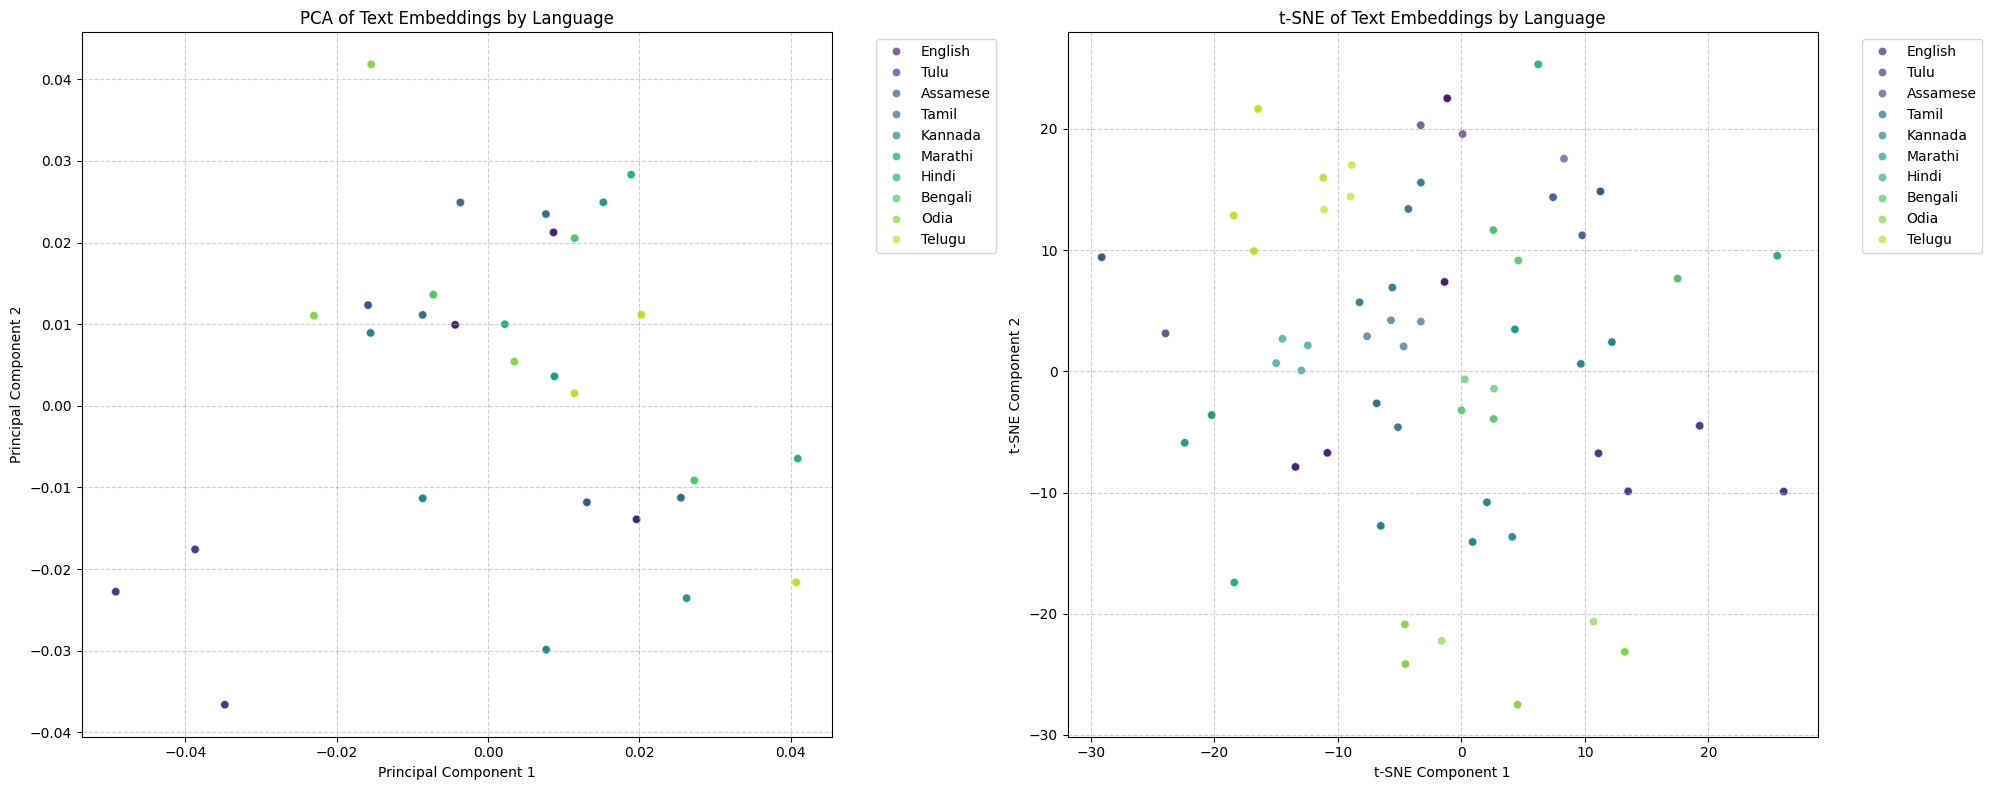

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(20, 8))

plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='language', palette='viridis', alpha=0.7)
plt.title('PCA of Text Embeddings by Language')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)

plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
sns.scatterplot(data=tsne_df, x='TSNE1', y='TSNE2', hue='language', palette='viridis', alpha=0.7)
plt.title('t-SNE of Text Embeddings by Language')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

## 9. Language Classification with Embeddings

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

print("Starting Language Classification Task...")

# Prepare target variable: 'language' from eval_samples_dr
y_lang = eval_samples_dr['language'].reset_index(drop=True)

# --- Split Data for each embedding type ---

# Using original embeddings (embeddings_array_dr was generated from eval_samples_dr)
X_train_orig_lang, X_test_orig_lang, y_train_lang, y_test_lang = train_test_split(
    embeddings_array_dr, y_lang, test_size=0.3, random_state=42, stratify=y_lang
)

# Using PCA-reduced embeddings
X_train_pca_lang, X_test_pca_lang, _, _ = train_test_split(
    embeddings_pca, y_lang, test_size=0.3, random_state=42, stratify=y_lang
)

# Using t-SNE-reduced embeddings
X_train_tsne_lang, X_test_tsne_lang, _, _ = train_test_split(
    embeddings_tsne, y_lang, test_size=0.3, random_state=42, stratify=y_lang
)

print(f"\nTraining set size for language classification: {len(y_train_lang)}")
print(f"Test set size for language classification: {len(y_test_lang)}")

Starting Language Classification Task...

Training set size for language classification: 140
Test set size for language classification: 60


### 8.1 Training and Evaluation with Original Embeddings

In [ ]:
print("\n--- Training with Original Embeddings (High-Dim) for Language Classification ---")
model_orig_lang = LogisticRegression(max_iter=1000, random_state=42, solver='liblinear')
model_orig_lang.fit(X_train_orig_lang, y_train_lang)
y_pred_orig_lang = model_orig_lang.predict(X_test_orig_lang)
accuracy_orig_lang = accuracy_score(y_test_lang, y_pred_orig_lang)
print(f"Accuracy (Original Embeddings): {accuracy_orig_lang:.4f}")
print("Classification Report (Original Embeddings):")
print(classification_report(y_test_lang, y_pred_orig_lang, zero_division=0))


--- Training with Original Embeddings (High-Dim) for Language Classification ---
Accuracy (Original Embeddings): 0.1333
Classification Report (Original Embeddings):
              precision    recall  f1-score   support

    Assamese       0.00      0.00      0.00         6
     Bengali       0.00      0.00      0.00         5
     English       0.00      0.00      0.00         5
       Hindi       0.00      0.00      0.00         5
     Kannada       0.00      0.00      0.00         7
     Marathi       0.00      0.00      0.00         5
        Odia       0.00      0.00      0.00         7
       Tamil       0.00      0.00      0.00         5
      Telugu       0.00      0.00      0.00         7
        Tulu       0.13      1.00      0.24         8

    accuracy                           0.13        60
   macro avg       0.01      0.10      0.02        60
weighted avg       0.02      0.13      0.03        60



### 8.2 Training and Evaluation with PCA-Reduced Embeddings

In [ ]:
print("\n--- Training with PCA Features for Language Classification ---")
model_pca_lang = LogisticRegression(max_iter=1000, random_state=42, solver='liblinear')
model_pca_lang.fit(X_train_pca_lang, y_train_lang)
y_pred_pca_lang = model_pca_lang.predict(X_test_pca_lang)
accuracy_pca_lang = accuracy_score(y_test_lang, y_pred_pca_lang)
print(f"Accuracy (PCA): {accuracy_pca_lang:.4f}")
print("Classification Report (PCA):")
print(classification_report(y_test_lang, y_pred_pca_lang, zero_division=0))


--- Training with PCA Features for Language Classification ---
Accuracy (PCA): 0.1333
Classification Report (PCA):
              precision    recall  f1-score   support

    Assamese       0.00      0.00      0.00         6
     Bengali       0.00      0.00      0.00         5
     English       0.00      0.00      0.00         5
       Hindi       0.00      0.00      0.00         5
     Kannada       0.00      0.00      0.00         7
     Marathi       0.00      0.00      0.00         5
        Odia       0.00      0.00      0.00         7
       Tamil       0.00      0.00      0.00         5
      Telugu       0.00      0.00      0.00         7
        Tulu       0.13      1.00      0.24         8

    accuracy                           0.13        60
   macro avg       0.01      0.10      0.02        60
weighted avg       0.02      0.13      0.03        60



### 8.3 Training and Evaluation with t-SNE-Reduced Embeddings

In [ ]:
print("\n--- Training with t-SNE Features for Language Classification ---")
model_tsne_lang = LogisticRegression(max_iter=1000, random_state=42, solver='liblinear')
model_tsne_lang.fit(X_train_tsne_lang, y_train_lang)
y_pred_tsne_lang = model_tsne_lang.predict(X_test_tsne_lang)
accuracy_tsne_lang = accuracy_score(y_test_lang, y_pred_tsne_lang)
print(f"Accuracy (t-SNE): {accuracy_tsne_lang:.4f}")
print("Classification Report (t-SNE):")
print(classification_report(y_test_lang, y_pred_tsne_lang, zero_division=0))


--- Training with t-SNE Features for Language Classification ---
Accuracy (t-SNE): 0.4167
Classification Report (t-SNE):
              precision    recall  f1-score   support

    Assamese       0.00      0.00      0.00         6
     Bengali       0.00      0.00      0.00         5
     English       0.00      0.00      0.00         5
       Hindi       0.00      0.00      0.00         5
     Kannada       0.00      0.00      0.00         7
     Marathi       1.00      0.60      0.75         5
        Odia       0.47      1.00      0.64         7
       Tamil       0.00      0.00      0.00         5
      Telugu       0.78      1.00      0.88         7
        Tulu       0.73      1.00      0.84         8

    accuracy                           0.42        60
   macro avg       0.30      0.36      0.31        60
weighted avg       0.33      0.42      0.35        60



### 8.4 Visualizing Model Accuracy Comparison for Language Classification

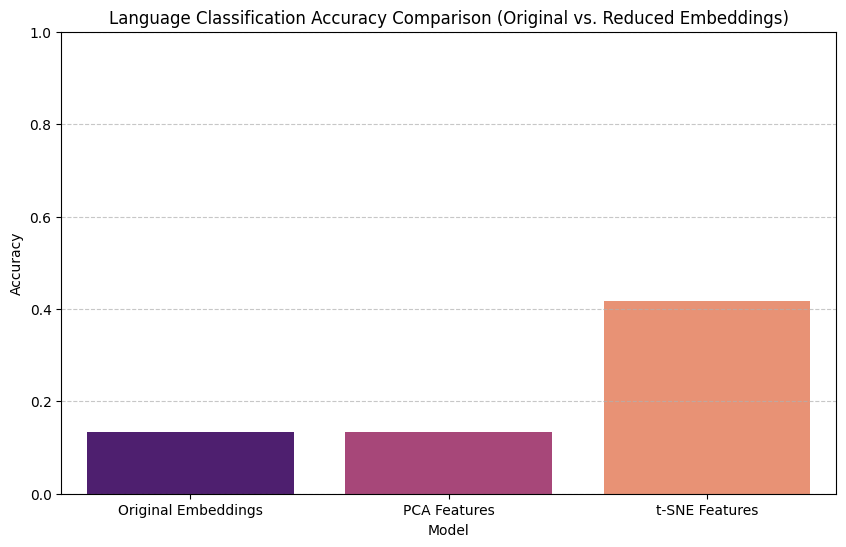


--- Conclusion on Language Classification Model Comparison ---
By comparing the accuracy scores, we can assess which embedding type (original, PCA, or t-SNE) leads to better performance for the language classification task.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

accuracy_scores_lang = {
    'Original Embeddings': accuracy_orig_lang,
    'PCA Features': accuracy_pca_lang,
    't-SNE Features': accuracy_tsne_lang
}

metrics_df_lang = pd.DataFrame(accuracy_scores_lang.items(), columns=['Model', 'Accuracy'])

plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='Accuracy', data=metrics_df_lang, palette='magma')
plt.title('Language Classification Accuracy Comparison (Original vs. Reduced Embeddings)')
plt.ylabel('Accuracy')
plt.ylim(0, 1) # Accuracy is between 0 and 1
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print("\n--- Conclusion on Language Classification Model Comparison ---")
print("By comparing the accuracy scores, we can assess which embedding type (original, PCA, or t-SNE) leads to better performance for the language classification task.")

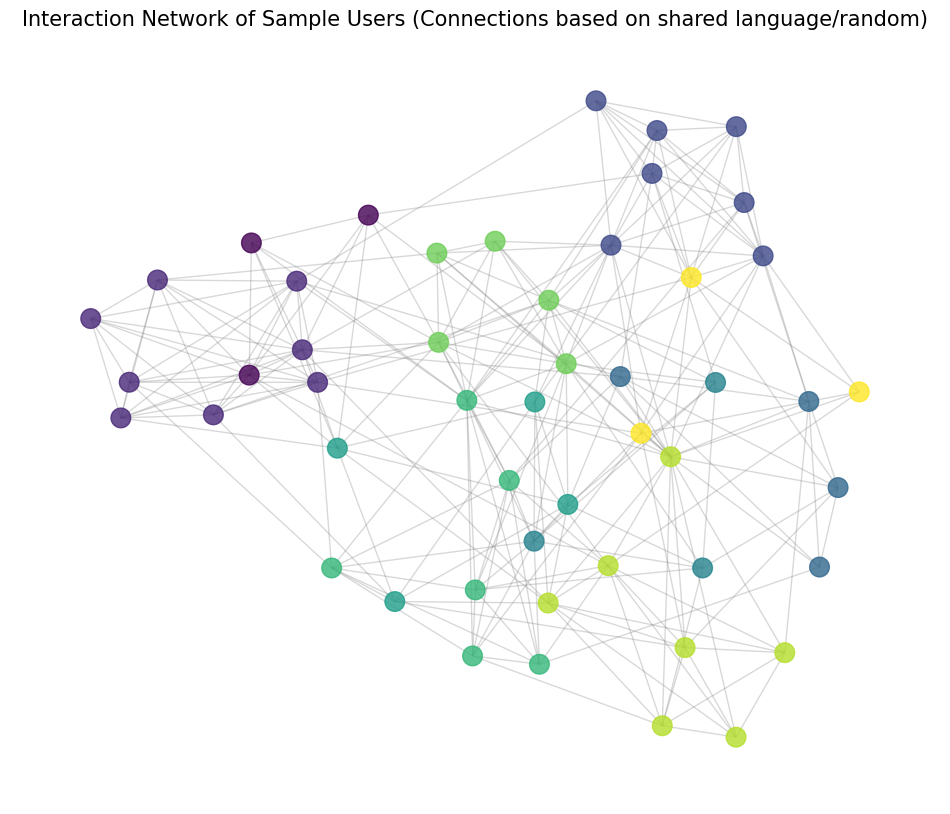

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

# Get a sample of unique users for the network graph
# Limiting to a smaller number of users for clearer visualization
unique_users = df['user_id'].unique()
num_nodes = min(50, len(unique_users)) # Adjust as needed
sample_users = np.random.choice(unique_users, num_nodes, replace=False)

# Create a graph
G = nx.Graph()

# Add nodes to the graph
G.add_nodes_from(sample_users)

# Add edges based on a shared attribute (e.g., same language) for demonstration
# For simplicity, we'll connect users if they have at least one post in common language

user_languages = df[df['user_id'].isin(sample_users)].groupby('user_id')['language'].apply(lambda x: list(x.unique()))

for i, user1 in enumerate(sample_users):
    for j, user2 in enumerate(sample_users):
        if i < j: # Avoid duplicate edges and self-loops
            # Check for common languages
            if any(lang in user_languages.get(user2, []) for lang in user_languages.get(user1, [])):
                G.add_edge(user1, user2)
            # Optionally, add some random edges to make the graph more connected
            elif random.random() < 0.05: # 5% chance of random connection
                 G.add_edge(user1, user2)


# --- Visualization ---
plt.figure(figsize=(12, 10))

# Get node colors based on language (or just a default color)
node_colors = []
language_map = {lang: i for i, lang in enumerate(df['language'].unique())}

for user in G.nodes():
    # Get the language of the first post found for this user in the sample_users subset
    lang = df[df['user_id'] == user]['language'].iloc[0] if not df[df['user_id'] == user].empty else 'Unknown'
    node_colors.append(language_map.get(lang, -1)) # Assign a unique color index

# Draw the graph
pos = nx.spring_layout(G, k=0.3, iterations=50) # Position nodes using Fruchterman-Reingold force-directed algorithm
nx.draw_networkx_nodes(G, pos, node_color=node_colors, cmap=plt.cm.viridis, node_size=200, alpha=0.8)
nx.draw_networkx_edges(G, pos, width=1.0, alpha=0.3, edge_color='gray')
# nx.draw_networkx_labels(G, pos, font_size=8, font_color='black') # Uncomment to show labels if desired

plt.title('Interaction Network of Sample Users (Connections based on shared language/random)', size=15)
plt.axis('off') # Hide axes
plt.show()

In [ ]:
import plotly.express as px
import pandas as pd
from IPython.display import display
import ipywidgets as widgets

df = df.copy()

# ===== REQUIRED COLUMNS =====

df['detected_language'] = df.get('detected_language', 'Unknown')
df['interaction.likes'] = df.get('interaction.likes', 0)
df['interaction.comments'] = df.get('interaction.comments', 0)
df['interaction.shares'] = df.get('interaction.shares', 0)
df['translated_caption'] = df.get('translated_caption', '')

# ===== DROPDOWN =====

lang_dropdown = widgets.Dropdown(
    options=sorted(df['detected_language'].unique()),
    value=sorted(df['detected_language'].unique())[0],
    description='Language:',
    layout=widgets.Layout(width='50%')
)

output = widgets.Output()

def update_dashboard(change):
    with output:
        output.clear_output()

        selected_lang = lang_dropdown.value
        filtered_df = df[df['detected_language'] == selected_lang].head(500)

        # ===== KPI =====
        total_likes = int(filtered_df['interaction.likes'].sum())
        total_comments = int(filtered_df['interaction.comments'].sum())
        total_shares = int(filtered_df['interaction.shares'].sum())

        print("🌍 LANGUAGE INSIGHTS DASHBOARD")
        print(f"Selected Language: {selected_lang}")
        print(f"👍 Likes: {total_likes} | 💬 Comments: {total_comments} | 🔁 Shares: {total_shares}")
        print("-" * 60)

        # ===== 1. LANGUAGE DISTRIBUTION =====
        lang_counts = df['detected_language'].value_counts().reset_index()
        lang_counts.columns = ['language', 'count']

        fig1 = px.bar(
            lang_counts,
            x='language',
            y='count',
            title="🌍 Language Distribution",
            color='language'
        )
        fig1.show()

        # ===== 2. ENGAGEMENT SCATTER =====
        fig2 = px.scatter(
            filtered_df,
            x='interaction.likes',
            y='interaction.comments',
            size='interaction.shares',
            title="📊 Engagement by Language"
        )
        fig2.show()

        # ===== 3. LIKES DISTRIBUTION =====
        fig3 = px.histogram(
            filtered_df,
            x='interaction.likes',
            nbins=30,
            title="📈 Likes Distribution"
        )
        fig3.show()

        # ===== 4. TRANSLATION LENGTH COMPARISON =====
        filtered_df['orig_len'] = filtered_df['text_caption'].astype(str).apply(len)
        filtered_df['trans_len'] = filtered_df['translated_caption'].astype(str).apply(len)

        fig4 = px.scatter(
            filtered_df,
            x='orig_len',
            y='trans_len',
            title="🔁 Translation Length Comparison (Original vs Translated)"
        )
        fig4.show()

        # ===== 5. SAMPLE VIEWER =====
        print("\n📝 SAMPLE TRANSLATIONS:")
        display(filtered_df[['text_caption', 'translated_caption']].head(5))

# ===== RUN =====

lang_dropdown.observe(update_dashboard, names='value')

display(lang_dropdown)
display(output)

update_dashboard(None)


Dropdown(description='Language:', layout=Layout(width='50%'), options=('as', 'bn', 'en', 'hi', 'kn', 'mr', 'or…

Output()